In [1]:
# Jupyter-specific commands to auto-reload external modules and display plots inline
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, sys
import pandas as pd
from typing import cast, Optional
import re
import json
import glob

# Ensure project root directory
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

sys.path.append(os.getcwd())
project_root = os.getcwd()

print(f"Working Directory set to: {os.getcwd()}")

# Preprocessing Imports
from utils.trajectory_processing.trajectories_to_pixel_space import trajectories_to_pixel_space

# Simulation Imports
from src.simulate_fits_data import simulate_fits_data

# Detection Pipeline Imports
from src.process_fits_files import process_fits_directory 

# Tracking Imports
from utils.config_loader import TrackerConfig
from src.tomht import TOMHTTracker
from utils.post_process import (
    plot_longest_tracks,
    animate_tracks,
    print_tomht_stats,
    compute_mota,
    compute_mota,
    compute_motp,
    compute_ttft,
)

Working Directory set to: d:\tanne\Documents\cso_tomht


In [2]:
# --- PIPELINE CONFIGURATION ---
CONFIG_FILE_PATH = "config/parameters.jsonx"
TARGET_TRAJECTORY_CSV_FOLDER = "data/project_data/case_3"
DETECTIONS_CSV_OUTPUT = "results/detections/master_detections_with_covariance.csv"
INPUT_FITS_DIR = "results/simulated_data/fits"
OUTPUT_CSV_DIR = "results/detections"
OUTPUT_PLOT_DIR = "results/detection_frames"

# if results directory exists from a previous run, clear it out to avoid confusion with old files
if os.path.exists("results"):
    print("Clearing existing results directory...")
    for root, dirs, files in os.walk("results", topdown=False):
        for name in files:
            os.remove(os.path.join(root, name))
        for name in dirs:
            os.rmdir(os.path.join(root, name))

# Ensure the master results directory exists
os.makedirs("results", exist_ok=True)

Clearing existing results directory...


In [3]:
# --- HELPER FUNCTION ---
def load_json_with_comments(filepath):
    """Loads a JSON file that contains // or /* */ comments."""
    with open(filepath, 'r') as f:
        content = f.read()
    content = re.sub(r'//.*?\n|/\*.*?\*/', '', content, flags=re.S)
    return json.loads(content)

def simulate_data(trajectory_folder: str, config: dict):
    """Step 1: Converts RIC trajectories to pixel space, then generates synthetic FITS."""
    print("\n" + "="*40)
    print(" STEP 1: SIMULATING IMAGE DATA")
    print("="*40)
    
    # Gather all CSV files in the target folder
    csv_files = glob.glob(os.path.join(trajectory_folder, "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {trajectory_folder}")
    
    # Build the dictionary mapping IDs to filepaths dynamically
    trajectory_files = {}
    for filepath in csv_files:
        obj_id = os.path.splitext(os.path.basename(filepath))[0] 
        trajectory_files[obj_id] = filepath
        
    print(f"Found {len(trajectory_files)} object trajectories: {list(trajectory_files.keys())}")
    
    # Convert kinematics to sensor pixel coordinates
    print("Converting CW frame dynamics to optical pixel coordinates...")
    pixel_trajectory_df = trajectories_to_pixel_space(trajectory_files, config)
    
    # Save the combined pixel trajectories to a master CSV 
    os.makedirs("results", exist_ok=True)
    master_pixel_csv = os.path.join("results", "master_pixel_trajectories.csv")
    pixel_trajectory_df.to_csv(master_pixel_csv, index=False)
    print(f"Saved merged pixel trajectories to {master_pixel_csv}")

    # Call data simulation function
    simulate_fits_data(master_pixel_csv, config=config, verbose=True)

# --- EXECUTION ---
# Load the configuration file
pipeline_config = load_json_with_comments(CONFIG_FILE_PATH)

# Execute data simulation step
simulate_data(trajectory_folder=TARGET_TRAJECTORY_CSV_FOLDER, config=pipeline_config)


 STEP 1: SIMULATING IMAGE DATA
Found 10 object trajectories: ['Debris_01_Random_state_results_debris_01_random', 'Debris_02_Random_state_results_debris_02_random', 'Debris_03_Random_state_results_debris_03_random', 'Debris_04_Random_state_results_debris_04_random', 'Debris_05_Random_state_results_debris_05_random', 'Debris_06_Random_state_results_debris_06_random', 'Debris_07_Random_state_results_debris_07_random', 'Debris_08_Random_state_results_debris_08_random', 'Debris_09_Random_state_results_debris_09_random', 'Debris_10_Random_state_results_debris_10_random']
Converting CW frame dynamics to optical pixel coordinates...
Saved merged pixel trajectories to results\master_pixel_trajectories.csv
[*] Loading trajectory: results\master_pixel_trajectories.csv
[*] Downsampling trajectory to a 1-second image capture rate...
[*] Running simulation logic on 490 frames...
[+] Simulation core complete. Generating artifacts...
[✓] Simulation successful. Outputs saved to: results/simulated_data

In [4]:
def detect_sources(input_dir: str, output_csv: str, output_plot: str):
    """Step 2: Runs background subtraction and matched filtering on the simulated FITS files."""
    print("\n" + "="*40)
    print(" STEP 2: SOURCE DETECTION (MATCHED FILTER)")
    print("="*40)
    
    process_fits_directory(
        input_dir=input_dir, 
        output_csv_dir=output_csv, 
        output_plot_dir=output_plot,
        sigma_psf=0.5, 
        threshold_factor=5.0,
        skip_bg_sub=False,
        verbose=True,
        generate_gif=False
    )

# Execute detection step
detect_sources(
    input_dir=INPUT_FITS_DIR,
    output_csv=OUTPUT_CSV_DIR,
    output_plot=OUTPUT_PLOT_DIR
)


 STEP 2: SOURCE DETECTION (MATCHED FILTER)
[*] Starting Detection: 49 frames (USING BKG Subtraction)
[+] Processing Frame 49/49[✓] Saved 351 detections to CSV.



 STEP 3: TOMHT MULTI-TARGET TRACKING
[*] Running TOMHT over 351 pipeline detections...
--------------------------------------------------
TOMHT PERFORMANCE SUMMARY
--------------------------------------------------
Frames Processed      : 49
Raw Detections        : 351
Total Tracked Points  : 427
Unique Tracks Formed  : 16
--------------------------------------------------
 TRACK LIFESPAN METRICS
--------------------------------------------------
Max Track Length      : 42 frames
Average Track Length  : 26.7 frames
Short Tracks (<=5)    : 1
Medium Tracks (6-20)  : 2
Long Tracks (>20)     : 13

[*] Generating visualization artifacts...


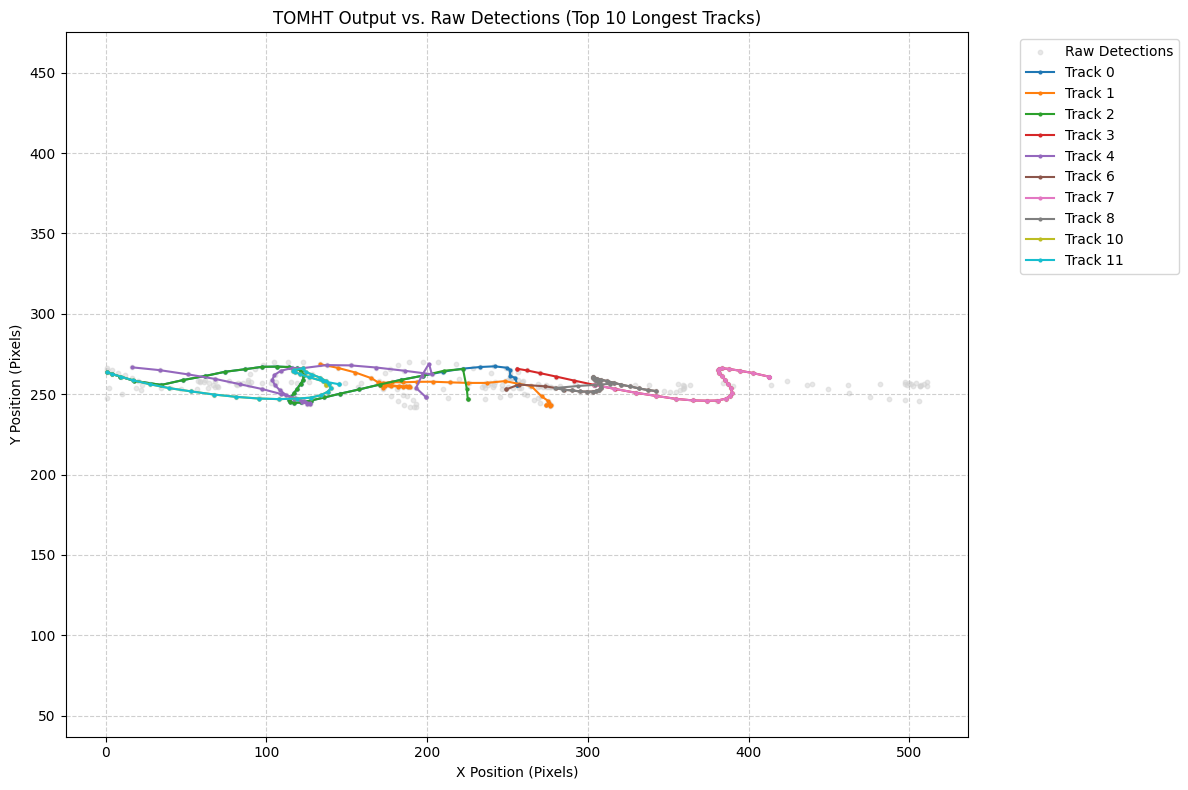

Saved track plot to results/tomht_eval/tomht_longest_tracks.png
Saved animation to results/tomht_eval/tomht_animation.gif
[✓] Tracker visualizations saved to: results/tomht_eval/

 END-TO-END TOMHT TRACKING COMPLETE


In [5]:
def run_tracker(csv_path: str, generate_gif: bool = False, verbose: bool = True):
    """Step 3: Runs the TOMHT Tracker over the detections generated in Step 2."""
    print("\n" + "="*40)
    print(" STEP 3: TOMHT MULTI-TARGET TRACKING")
    print("="*40)
    
    output_dir = "results/tomht_eval/"
    os.makedirs(output_dir, exist_ok=True)
    
    raw_df = pd.read_csv(csv_path)
    raw_df = raw_df.rename(columns={'Frame_Idx': 'time', 'Centroid_X': 'x', 'Centroid_Y': 'y'})


    if verbose: print(f"[*] Running TOMHT over {len(raw_df)} pipeline detections...")
    
    config = TrackerConfig.from_jsonx("config/parameters.jsonx")
    tracker = TOMHTTracker(config)
    n_scan = config.n_scan_window 
    results = []
    
    # Tracking Loop
    unique_times = raw_df['time'].unique()
    for i, (t_raw, group) in enumerate(raw_df.groupby('time')):
        t = cast(int, t_raw) 
        meas_t = group[['x', 'y']].to_numpy()
        active_tracks = tracker.step(meas_t)

        for track in active_tracks:
            if len(track.best_hypothesis.history_states) >= n_scan: 
                delayed_state = track.best_hypothesis.history_states[-n_scan]
                results.append({
                    'time': t - n_scan,
                    'id': track.track_id,
                    'x': delayed_state[0], 'y': delayed_state[1],
                    'vx': delayed_state[2], 'vy': delayed_state[3]
                })
        
        if not verbose:
            print(f"\r[+] Tracking Progress: {i+1}/{len(unique_times)} frames", end='', flush=True)

    if not verbose: print()

    tracked_df = pd.DataFrame(results)
    
    if tracked_df.empty:
        print("[!] Warning: Tracker returned no tracks. Check gating or noise parameters.")
    else:
        if verbose:
            print_tomht_stats(raw_df, tracked_df)
            print("[*] Generating visualization artifacts...")
        
        plot_longest_tracks(raw_df, tracked_df, os.path.join(output_dir, "tomht_longest_tracks.png"), display_plots=verbose)
        if generate_gif:
            animate_tracks(raw_df, tracked_df, os.path.join(output_dir, "tomht_animation.gif"))
        
        if verbose: print(f"[✓] Tracker visualizations saved to: {output_dir}")

    return tracked_df

# Execute tracking algorithm
tracked_df = run_tracker(csv_path=DETECTIONS_CSV_OUTPUT,generate_gif=True)

print("\n========================================")
print(" END-TO-END TOMHT TRACKING COMPLETE")
print("========================================")

In [6]:
# --- EVALUATION ---
GT_CSV_PATH = os.path.join(project_root, "results", "simulated_data", "ground_truth.csv")
gt_df = pd.read_csv(GT_CSV_PATH)

# Evaluate Tracking Performance
motp_score = compute_motp(gt_df, tracked_df, distance_threshold=10.0)
mota_score = compute_mota(gt_df, tracked_df, distance_threshold=10.0)
ttft_results = compute_ttft(gt_df, tracked_df, distance_threshold=2.0)

print(f"Tracking Performance:")
print(f" - MOTP (Precision): {motp_score:.3f} pixels average error")
print(f" - MOTA (Accuracy):  {mota_score:.3f}")


 TRACK LIFESPAN, INITIALIZATION, AND FRAGMENTATION SUMMARY
+-------------------------------------------------+---------------+-----------------------+-----------------+--------------------+--------------------+-----------------------+----------+
| Object_ID                                       |   Birth Frame |   First Tracked Frame |   TTFT (Frames) |   Initial Track ID |   Unique Track IDs |   Frags / ID Switches | Status   |
|-------------------------------------------------+---------------+-----------------------+-----------------+--------------------+--------------------+-----------------------+----------|
| Debris_01_Random_state_results_debris_01_random |             0 |                     0 |               0 |                  0 |                  3 |                     2 | Tracked  |
| Debris_02_Random_state_results_debris_02_random |             0 |                     1 |               1 |                  0 |                  3 |                    12 | Tracked  |
| Deb